In [80]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [81]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [82]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [83]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (147723346000)>


In [84]:
import openseespy.opensees as ops

#Soil Element Properties
elasto_mat_tag = 1
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"


# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

# Storage for created nodes and elements
created_nodes = []
created_elements = []
block_registry = {}

# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2, # number of dimension
            17.8, #rho kN /m3 , 1.8*UNIT.ton / UNIT.m3
            9600.0, # ref shear modulus kpa
            27000.0, #ref bulk modulus kPa
            36, # friction angle
            0.1, # peak stress unit less
            101.0, #reference pressure kpa
            0.0, # press Dependent coefficient 
            26, #PT angle
            0.067, # Contrac 1 unit less
            0.23, # Contrac 3 unit less
            0.06, # dilatation 1 unit less
            0.27, # dilatation 3 unit less
            20, #no Yield Surf
            5.0, #Contrac 2 unit less
            3.0, #Contrac 3 unit less
            1.0, # liquefac1
            0.0, # liquefac2
            0.77, # e
            0.9, # cs1
            0.02, # cs2
            0.7, # cs3
            101.0, # pa kPa
        )
        # element thickness
        # body force in x-direction
        # body force in y-direction
        # create wrapper material for initial state analysis
soil_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

    #elasto_mat_tag = 100
    # Define material
    #ops.nDMaterial("ElasticIsotropic", elasto_mat_tag, E, nu, rho)

    # Define contact material
contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0) #kN/m

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
#node_offset, elem_offset = SF.generate_block(-16, 0.0, 32.0, 12.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 2.0, 2.0 ,block_name="OAE_Soil_block")
#node_offset, elem_offset = SF.generate_block(-16, 13.5, 32.0, 4.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 1.0, 1.0 ,block_name="OAE_small_block")
node_offset, elem_offset = SF.generate_block(-3.5, 18.0, 3.0, 2.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_little_small_block")
node_offset, elem_offset = SF.generate_block(0.5, 18.0, 3.0, 2.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_little_smalla_block")

In [85]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [86]:
# last_elid = SF.get_next_elem_id(start_from=None)
# 
# bottom_nodes = list(range(103, 120))   # [103, 104, 105, 106, 107, 108]
# top_nodes = list(range(120, 153))      # [120, 121, ..., 130]
# 
# patch = SF.create_ring_triangles(bottom_nodes = bottom_nodes, top_nodes = top_nodes, start_elem_id = last_elid, etype = etype, mat_tag = soil_mat_tag, thickness = soil_thickness, block_name="ring_triangles")

In [87]:
# last_elid = SF.get_next_elem_id(start_from=None)
# bottom_nodes = list(range(252, 268))
# top_nodes = list(range(285, 316))
# 
# patch = SF.create_ring_triangles(bottom_nodes = bottom_nodes, top_nodes = top_nodes, start_elem_id = last_elid, etype = etype, mat_tag = soil_mat_tag, thickness = soil_thickness, block_name="ringa_triangles")

In [88]:
# last_elid = SF.get_next_elem_id(start_from=None)
# bottom_nodes = list(range(269, 285))
# top_nodes = list(range(478, 509))
# 
# patch = SF.create_ring_triangles(bottom_nodes = bottom_nodes, top_nodes = top_nodes, start_elem_id = last_elid, etype = etype, mat_tag = soil_mat_tag, thickness = soil_thickness, block_name="ringb_triangles")

In [89]:
start_id = SF.get_next_node_id()

In [90]:
interface_coor = [
[0.000 ,  18.000],
[0.000 ,  19.000],
[0.000 ,  19.500],
[0.000 ,  20.000],
[0.000 ,  20.500],
]

interface_node = SF.add_nodes_from_coordinates(coord_list = interface_coor, start_id = start_id, block_name = "interface_node")

In [91]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [92]:
# last_elid = SF.get_next_elem_id(start_from=None)
# bottom_nodes = [267, 268, 269]
# top_nodes = [315, 316, 669, 477, 478]
# 
# patch = SF.create_ring_triangles(bottom_nodes = bottom_nodes, top_nodes = top_nodes, start_elem_id = last_elid, etype = etype, mat_tag = soil_mat_tag, thickness = soil_thickness, block_name="ringc_triangles")

In [93]:
last_elid = SF.get_next_elem_id(start_from=None)
# right_nodes = [380, 412, 444, 476]
# left_nodes = [670, 671, 672, 673]

right_nodes = [86, 87, 88, 89]
left_nodes = [21, 28, 35, 42]

quada_patch = SF.create_quad_strip_from_nodes(edge1_nodes = left_nodes, edge2_nodes = right_nodes, 
                                             start_elem_id = last_elid, thickness = soil_thickness, 
                                             etype = etype, mat_tag = soil_mat_tag, block_name="quada_strip")

In [94]:
last_elid = SF.get_next_elem_id(start_from=None)
# right_nodes = [670, 671, 672, 673]
# left_nodes = [541, 573, 605, 637]

right_nodes = [86, 87, 88, 89]
left_nodes = [57, 64, 71, 78]

quadb_patch = SF.create_quad_strip_from_nodes(edge1_nodes = left_nodes, edge2_nodes = right_nodes, 
                                             start_elem_id = last_elid, thickness = soil_thickness, 
                                             etype = etype, mat_tag = soil_mat_tag, block_name="quadb_strip")

In [95]:
start_id = SF.get_next_node_id()
last_elid = SF.get_next_elem_id(start_from=None)
slave_coor_node = [
[ 0.0000 , 18.7000],
[-0.1414 , 18.6414],
[-0.2000 , 18.5000],
[-0.1414 , 18.3586],
[ 0.0000 , 18.3000],
[ 0.1414 , 18.3586],
[ 0.2000 , 18.5000],
[ 0.1414 , 18.6414],
]

inter_node_b = [
[ 0.0000 , 18.8428],
[-0.2424 , 18.7424],
[-0.3428 , 18.5000],
[-0.2424 , 18.2576],
[ 0.0000 , 18.1572],
[ 0.2424 , 18.2576],
[ 0.3428 , 18.5000],
[ 0.2424 , 18.7424],    
]

quadc_b = SF.create_ring_quads(set_a_coords = inter_node_b, set_b_coords = slave_coor_node, start_node_id = start_id, start_elem_id = last_elid,
                      thickness = soil_thickness , etype = etype, mat_tag = soil_mat_tag, block_name="ring_quads")

In [96]:
#lining nodes 682 - 689
#lining nodes 398 - 405

In [97]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [98]:
last_elid = SF.get_next_elem_id(start_from=None)
# right_nodes = [670, 380, 348, 316, 669, 477, 509, 541, 670]
# left_nodes = [674, 675, 676, 677, 678, 679, 680, 681, 674]

right_nodes = [98, 99, 100, 101, 102, 103, 104, 105, 98]
left_nodes = [86, 21, 14, 7, 85, 43, 50, 57, 86]

quadd_patch = SF.create_quad_strip_from_nodes(edge1_nodes = left_nodes, edge2_nodes = right_nodes, 
                                             start_elem_id = last_elid, thickness = soil_thickness, 
                                             etype = etype, mat_tag = soil_mat_tag, block_name="quadd_strip")

In [99]:
bot_fixY = SF.fix_nodes_by_range(start_id =2, end_id = 7, step =1, fixity = fixYonly, block_name="fixed_nodes_bottom")
bot_fixY = SF.fix_nodes_by_range(start_id =43, end_id = 48, step =1, fixity = fixYonly, block_name="fixed_nodes_bottom")
ops.fix(85, *fixYonly)
ops.fix(1, *fixXY)
ops.fix(49, *fixXY)

In [100]:
# eqdof = SF.apply_equal_dof_by_range(
#     primary_start = 18 , primary_end = 103, primary_step = 17,
#     secondary_start = 34, secondary_end = 119, secondary_step = 17,
#     dofs=[1, 2], block_name="equal_dof_constraints")

In [101]:
# eqdof = SF.apply_equal_dof_by_range(
#     primary_start = 120 , primary_end = 252, primary_step = 33,
#     secondary_start = 152, secondary_end = 284, secondary_step = 33,
#     dofs=[1, 2], block_name="equal_dof_constraints")

In [102]:
eqdof = SF.apply_equal_dof_by_range(
    primary_start = 8, primary_end = 36, primary_step = 7,
    secondary_start = 56, secondary_end = 84, secondary_step = 7,
    dofs=[1, 2], block_name="equal_dof_constraints")

In [103]:
# start_id = SF.get_next_node_id()
# LagrangeN = SF.create_lagrange_nodes(start_id = start_id, x_coord = 0.75 , y_coord = 18.25, count = 8, block_name="LN_nodes")

In [104]:
# start_id = SF.get_next_node_id()
# LagrangeNB = SF.create_lagrange_nodes(start_id = start_id, x_coord = 2.7552 , y_coord = 20.75, count = 10, block_name="LNB_nodes")

In [105]:
ops.model("Basic", "-ndm", 2, "-ndf", 3)

In [106]:
start_id = SF.get_next_node_id()
lining_nodes_coor = [
[ 0.0000 , 18.7000],
[-0.1414 , 18.6414],
[-0.2000 , 18.5000],
[-0.1414 , 18.3586],
[ 0.0000 , 18.3000],
[ 0.1414 , 18.3586],
[ 0.2000 , 18.5000],
[ 0.1414 , 18.6414],
]

lining_noodes = SF.add_nodes_from_coordinates(coord_list = lining_nodes_coor, start_id = start_id, block_name = "lining_nodes")

In [107]:
print(lining_noodes)

[106, 107, 108, 109, 110, 111, 112, 113]


In [108]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [109]:
lining_soil = SF.apply_equal_dof_by_range(
    primary_start = 106, primary_end = 113, primary_step = 1,
    secondary_start = 98, secondary_end = 105, secondary_step = 1,
    dofs=[1, 2], block_name="equal_dof_constraints")

In [110]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.02)
print(Iz)

6.666666666666668e-07


In [111]:
lining_noodes = lining_noodes + [106] #708 if added the 1st lagrange node set
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.02*UNIT.m2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAM = SF.create_disp_beam_column_chain(beam_nodes = lining_noodes, beam_start_id = 5000,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

In [112]:
#lining_slave_nodes = [682,683,684,685,686,687,688,689 ]

In [113]:
# CONTACT_B = SF.create_beam_contact_chain(master_nodes = lining_noodes, slave_nodes = lining_slave_nodes, lagrange_nodes = LagrangeN,
#                                contact_mat = contact_mat, beam_start_id = 3050,
#                                width=1000*UNIT.mm, tol1=1e-10, tol2=1e-10,
#                                block_name="contact_beams")

In [114]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [115]:
start_id = SF.get_next_node_id()
pad_nodes_coor = [
[ 2.0000 , 20.5000],
[ 1.5000 , 20.5000],
[ 1.0000 , 20.5000],
[ 0.5000 , 20.5000],
[ 0.0000 , 20.5000],
[-0.5000 , 20.5000],
[-1.0000 , 20.5000],
[-1.5000 , 20.5000],
[-2.0000 , 20.5000],
[-2.5000 , 20.5000],
]

pad_nodes = SF.add_nodes_from_coordinates(coord_list = pad_nodes_coor, start_id = start_id, block_name = "pad_nodes_coor")

In [116]:
Iza = SF.FormRectangularInertia(b = 1.0, h = 0.3)
pad_nodes = pad_nodes + []
beam_secTag = 2
intTag = 402
Nint = 3

# Geometry transformation and section definition

ops.section("Elastic", beam_secTag, 32837*UNIT.mpa, 0.3*UNIT.m2, Iza*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAM = SF.create_disp_beam_column_chain(beam_nodes = pad_nodes, beam_start_id = 900,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

In [117]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [118]:
pad_slave_soil_nodes = [81, 80, 79, 78, 89, 42, 41, 40, 39, 38]

In [119]:
pad_soil = SF.apply_equal_dof_pairs(r_nodes = pad_nodes, c_nodes = pad_slave_soil_nodes , dofs=[1, 2], block_name="equal_dof_pairs")

In [120]:
#pad_slave_nodes = [640, 639, 638, 637, 673, 476, 475, 474, 473]
#pad_slave_nodes = [357, 356, 355, 353, 389, 192, 191, 190, 189]

In [121]:
#CONTACT_C = SF.create_beam_contact_chain(master_nodes = pad_nodes, slave_nodes = pad_slave_nodes, lagrange_nodes = LagrangeNB,
#                               contact_mat = contact_mat, beam_start_id = 4050,
#                               width=1000*UNIT.mm, tol1=1e-10, tol2=1e-10,
#                               block_name="contact_beams")

In [122]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [123]:
ops.fix(123, 1, 1, 0)
ops.fix(114, 1, 1, 0)

In [124]:
OPSVIS = opst.vis.pyvista

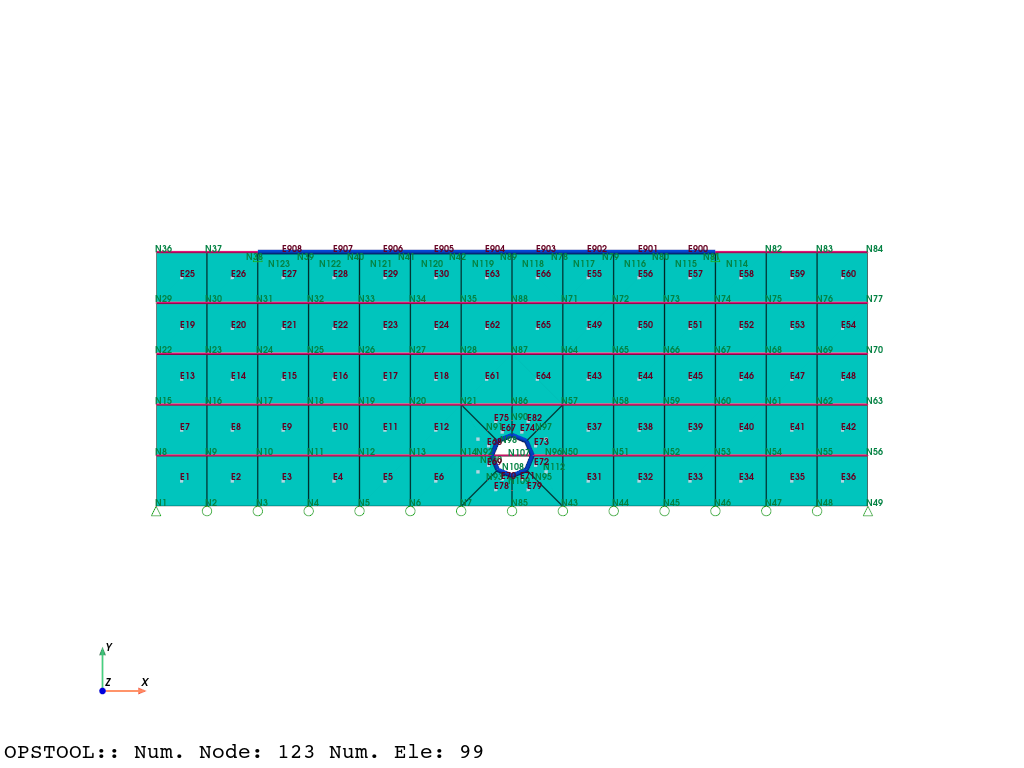

In [125]:
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [126]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [127]:
# define analysis parameters for gravity phase
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [128]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
#ops.setParameter("-val", 0, "-eleRange", 3050, 3057, "friction")
#ops.setParameter("-val", 0, "-eleRange", 4050, 4058, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON


In [129]:
# update soil material to consider elastoplastic behavior and analyze a few more steps
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
#ops.setParameter("-val", 0, "-eleRange", 3050, 3057, "friction")
#ops.setParameter("-val", 0, "-eleRange", 4050, 4058, "friction")

InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [130]:
# define analysis parameters for excavation phase
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 60)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("UmfPack") # BandGeneral # UmfPack
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [131]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [132]:
PN_1 = 20
print(PN_1)

20


In [133]:
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
#nodeTags = [115, 116, 117, 118, 119, 120, 121, 122]
opst.pre.transform_beam_uniform_load([900, 901, 902, 903, 904, 905, 906, 907, 908], wy=-5)

In [134]:
fig = opst.vis.plotly.plot_model(show_ele_loads=True, show_nodal_loads=True, load_scale=1)
fig.show()

In [135]:
ops.analyze(1)

0

In [136]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

after: 60 iterations  current Norm: 0.00891152 (max: 0.0001, Norm deltaR: 69.1501)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 3
OpenSees > analyze failed, returned: -3 error flag


Lift 1 removed


after: 60 iterations  current Norm: 0.400664 (max: 0.0001, Norm deltaR: 4069.23)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 3
OpenSees > analyze failed, returned: -3 error flag
after: 60 iterations  current Norm: 0.400664 (max: 0.0001, Norm deltaR: 4069.23)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 3
OpenSees > analyze failed, returned: -3 error flag


In [137]:
PN_2 = 50
print(PN_2)

50


In [138]:
#ops.load(420, 0, -PN_2, 0)

In [139]:
#ops.analyze(1)

In [140]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

#remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 2 removed")

Lift 2 removed


In [141]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [142]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [143]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

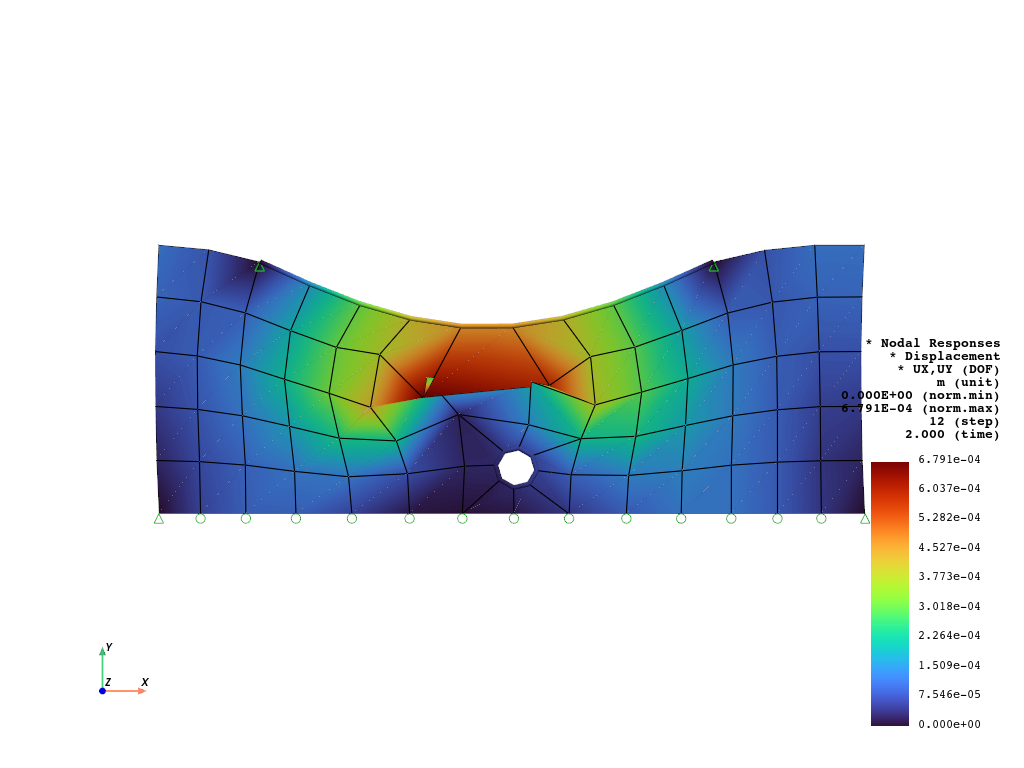

In [144]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

In [145]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=2,
    scale=2,
    savefig="NodalRespAnimationA.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved to NodalRespAnimationA.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

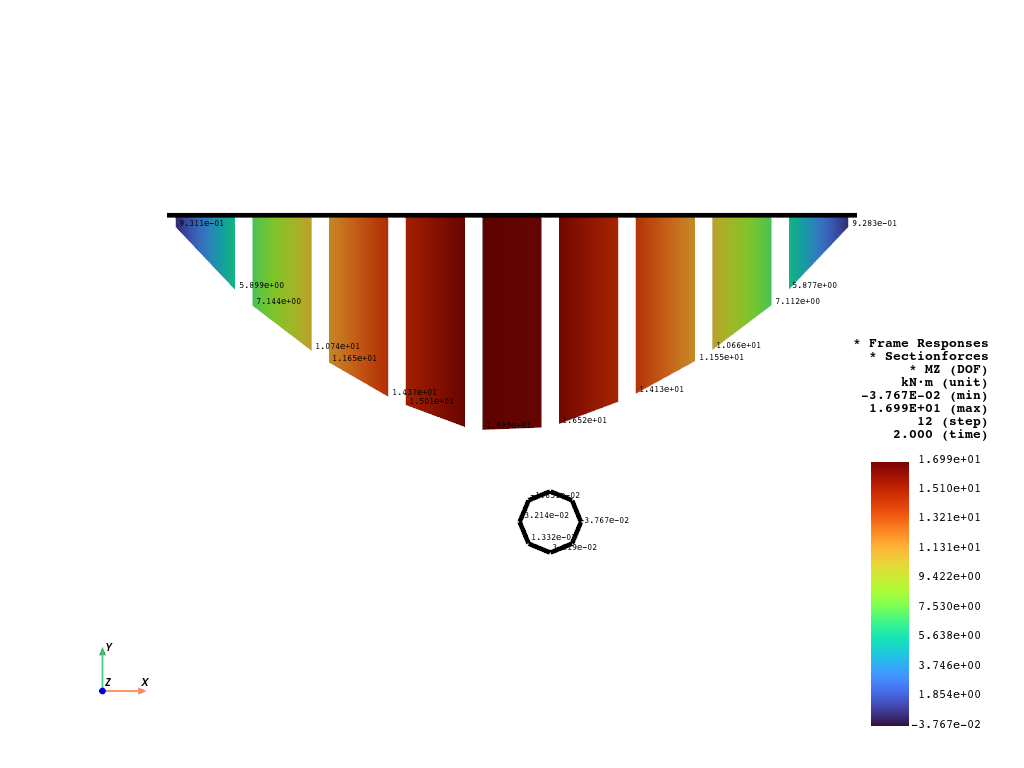

In [146]:
plotter = opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="jupyterlab")

In [147]:
opsvis.plot_frame_responses_animation(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    framerate=2,
    scale=3,
    line_width=4,
    savefig="FrameForcesMZ_A.gif",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved as FrameForcesMZ_A.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

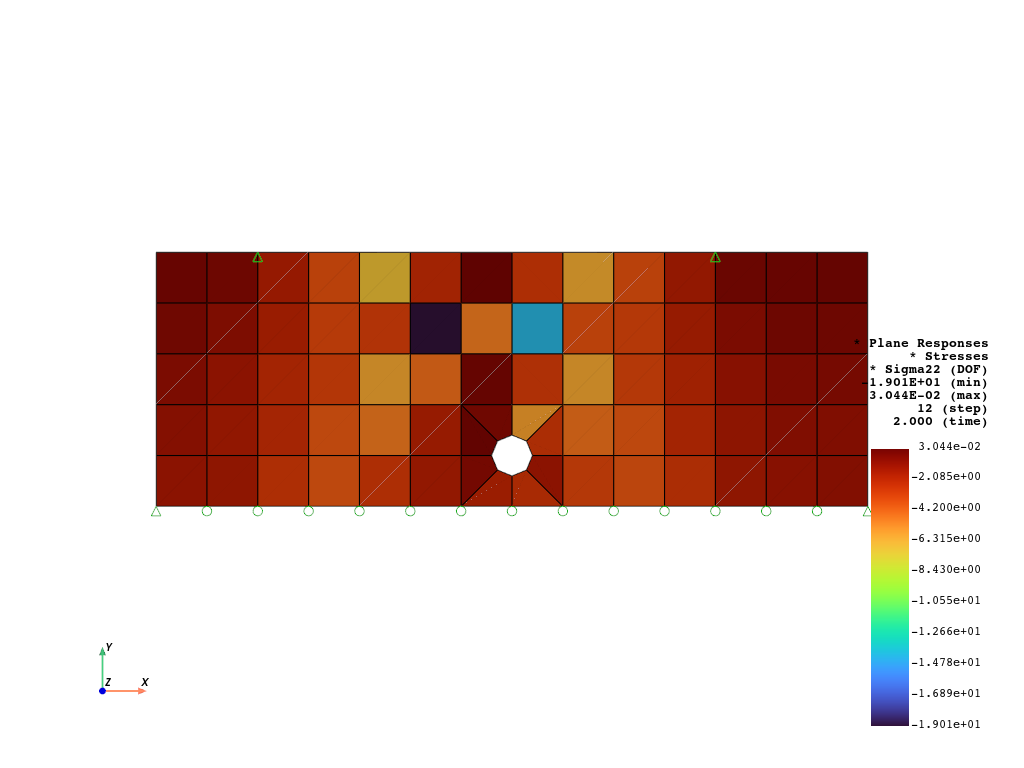

In [148]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22"
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

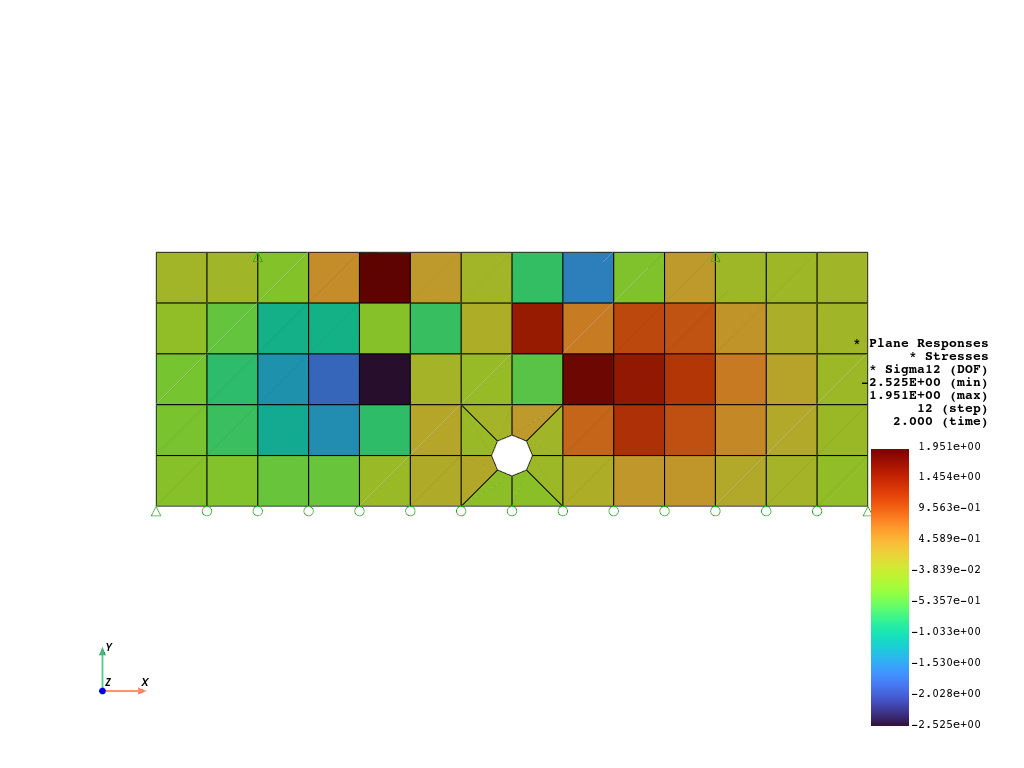

In [149]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma12"
).show(jupyter_backend="jupyterlab")

In [150]:
#data = opst.post.get_element_responses(odb_tag=1, ele_type="Contact")

In [151]:
#print(data)

In [152]:
# data["localForces"].sel(eleTags=3052).plot.line(x="time")
# plt.show()

In [153]:
#data["localForces"].sel(eleTags=907).plot.line(x="time")
#plt.show()

In [154]:
#data["localForces"].sel(eleTags=907).data

In [155]:
#data["localDisp"].sel(eleTags=3057).data

In [156]:
data_frame = opst.post.get_element_responses(odb_tag=1, ele_type="Frame")

OPSTOOL ::  Loading Frame response data from .opstool.output/RespStepData-1.nc ...

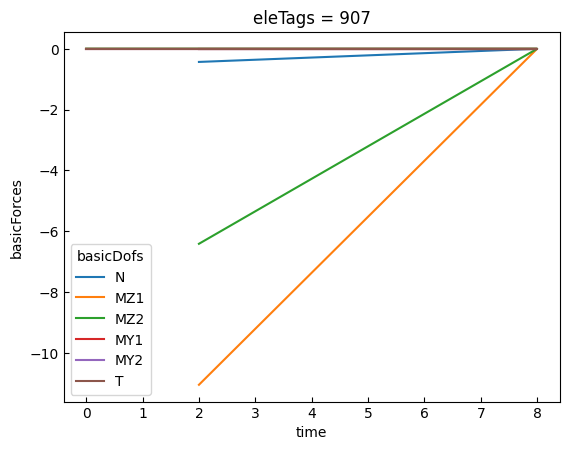

In [157]:
data_frame["basicForces"].sel(eleTags=907).plot.line(x="time")
plt.show()

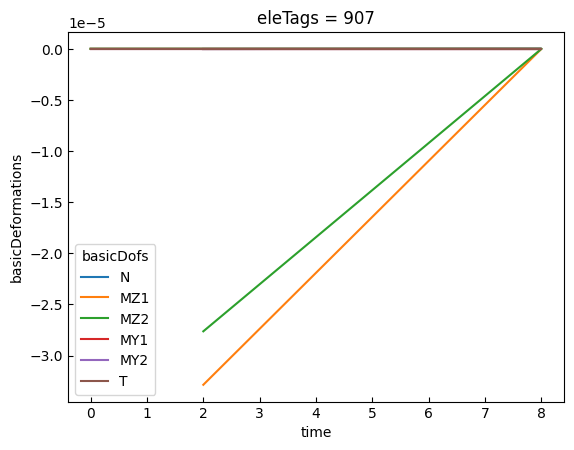

In [158]:
data_frame["basicDeformations"].sel(eleTags=907).plot.line(x="time")
plt.show()